# 1. Analysis Goal

본 노트북의 목적은 재정의된 학습 퍼널 구조를 기반으로,
각 단계에서의 전환 패턴과 이탈 요인을 분석하는 것이다.

특히 본 분석에서는 단순한 전환율 비교에 그치지 않고,
각 단계에서의 행동 변수와 전환 간의 관계를 통계적으로 검정하고,
이를 바탕으로 실제로 의미 있는 행동 기준(threshold)을 도출하는 것을 목표로 한다.

분석은 다음과 같은 절차로 진행된다:

1. 퍼널 전환율을 통해 전체 구조를 파악
2. 각 단계별로 집단 간 차이를 통계적으로 검정
3. 효과크기를 통해 실질적인 차이의 크기를 평가
4. 유의한 변수에 대해 threshold를 탐색 (PR 기반)
5. 해당 threshold가 실제로 구분력을 가지는지 재검증

이를 통해 각 퍼널 단계에서 학습자의 이탈이 발생하는 지점을 보다 구체적으로 이해하고,
운영 관점에서 개입 가능한 기준을 도출하고자 한다.

# 2. Load Preprocessed Data

본 분석에서는 전처리가 완료된 데이터를 불러와 사용한다.

전처리 과정에서는 결측값 처리, 이상값 제거, 퍼널 정합성 확보, 
그리고 파생 변수 생성 등이 수행되었으며, 해당 과정은 별도의 전처리 노트북에서 정리되어 있다.

본 노트북에서는 이러한 전처리 결과를 바탕으로,
퍼널 구조와 행동 변수 간의 관계를 분석하는 데 집중한다.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.metrics import precision_recall_curve, roc_curve

# 데이터 로드
df = pd.read_csv("course_final.csv")

# 기본 확인
df.shape

(533993, 31)

In [131]:
df.columns

Index(['course_id', 'userid_DI', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade',
       'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration',
       'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original',
       'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group',
       'exam_flag', 'LoE_num'],
      dtype='str')

# 2.1 Define Satisfied

본 분석에서는 기존 퍼널 구조에서 마지막 단계를 단순한 인증 여부로 정의하지 않고,
학습 행동을 기반으로 한 새로운 단계인 satisfied를 도입하였다.

이를 위해, 먼저 explored == 1이면서 certified == 1인 학습자를 기준으로
정상적인 학습 과정을 거친 집단을 정의하였다.

이 집단은 실제로 강의를 충분히 수강하고 인증 기준을 충족한 학습자들로,
각 강의에서 요구되는 학습량을 반영한다고 볼 수 있다.

이후 각 강의별 nchapters 분포에서 75th percentile을 계산하고,
해당 기준 이상으로 학습한 경우를 satisfied 상태로 정의하였다.

또한, 학습 경로의 일관성을 유지하기 위해,
explored 단계를 거치지 않은 경우는 satisfied에서 제외하였다.
이는 단순히 인증만을 목표로 한 비정상적 학습 패턴을 배제하고,
실제 학습 행동을 기반으로 한 집단을 정의하기 위함이다.

In [132]:
# 1. 정상 학습 기반 집단 정의
certified_clean = df[
    (df["certified"] == 1) &
    (df["explored"] == 1)
]

# 2. 강의별 nchapters 75% 지점 계산
p75_by_course = (
    certified_clean
    .groupby("course_id")["nchapters"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"nchapters": "nchapters_p75"})
)

# 3. merge
df = df.merge(p75_by_course, on="course_id", how="left")

# 4. satisfied 생성
df["satisfied"] = (
    (df["nchapters"] >= df["nchapters_p75"]) &
    (df["explored"] == 1)
).astype(int)

In [133]:
# 체크
df[(df["satisfied"] == 1) & (df["explored"] == 0)]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num,nchapters_p75,satisfied


# 3. Funnel Sanity Check

본 단계에서는 재정의된 퍼널 구조가 데이터 상에서 정상적으로 구성되어 있는지를 확인한다.

구체적으로는 각 단계별 학습자 수와 비율을 점검하고,
단계 간 논리적 일관성이 유지되는지를 확인한다.

이는 이후 전환율 분석 및 단계별 비교 분석을 수행하기에 앞서,
데이터가 분석 가능한 상태인지 검증하기 위한 과정이다.

In [134]:
# 단계별 인원 수
print("Registered:", df["registered"].sum())
print("Viewed:", df["viewed"].sum())
print("Explored:", df["explored"].sum())
print("Satisfied:", df["satisfied"].sum())

Registered: 533993
Viewed: 325361
Explored: 37584
Satisfied: 11870


In [135]:
# viewed 없이 explored 존재 여부
invalid_explore = df[(df["explored"] == 1) & (df["viewed"] != 1)]
print("Explored without Viewed:", len(invalid_explore))

# explored 없이 satisfied 존재 여부
invalid_satisfied = df[(df["satisfied"] == 1) & (df["explored"] != 1)]
print("Satisfied without Explored:", len(invalid_satisfied))

Explored without Viewed: 0
Satisfied without Explored: 0


### Observation

각 퍼널 단계는 전반적으로 논리적 순서를 따르고 있으며,
단계 간 역전되는 관측치는 거의 존재하지 않거나 제거된 상태임을 확인할 수 있다.

따라서 현재 데이터는 퍼널 기반 분석을 수행하기에 적절한 상태로 판단된다.

# 4. Funnel Conversion Rates

본 단계에서는 재정의된 퍼널 구조를 기반으로,
각 단계 간 전환율을 계산하여 학습자의 전체 흐름을 파악한다.

퍼널 전환율은 학습자가 다음 단계로 이동하는 비율을 의미하며,
이를 통해 학습 과정에서 이탈이 집중적으로 발생하는 구간을 식별할 수 있다.

이 분석은 이후 단계별 상세 분석을 위한 기준점으로 활용된다.

In [136]:
funnel_counts = {
    "Registered": df["registered"].sum(),
    "Viewed": df["viewed"].sum(),
    "Explored": df["explored"].sum(),
    "Satisfied": df["satisfied"].sum()
}

display(funnel_counts)

{'Registered': np.int64(533993),
 'Viewed': np.int64(325361),
 'Explored': np.int64(37584),
 'Satisfied': np.int64(11870)}

In [137]:
view_rate = df["viewed"].mean()

explore_rate = df[df["viewed"] == 1]["explored"].mean()

satisfaction_rate = df[df["explored"] == 1]["satisfied"].mean()

view_rate, explore_rate, satisfaction_rate

(np.float64(0.6092982492279861),
 np.float64(0.11551476667455535),
 np.float64(0.315825883354619))

In [138]:
funnel_df = pd.DataFrame({
    "Stage": ["Registered → Viewed", "Viewed → Explored", "Explored → Satisfied"],
    "Conversion Rate": [view_rate, explore_rate, satisfaction_rate]
})

display(funnel_df)

,Stage,Conversion Rate
0,Registered → Viewed,0.609298
1,Viewed → Explored,0.115515
2,Explored → Satisfied,0.315826


### Observation

퍼널 전환율을 살펴본 결과, Viewed → Explored 구간에서
전환율이 약 11.6%로 가장 낮게 나타났다.

이는 학습자가 강의에 진입한 이후 실제 학습으로 이어지지 않는 경우가
상당히 많음을 의미하며, 해당 구간이 주요 이탈 지점으로 작용하고 있음을 시사한다.

반면, Explored 이후 구간에서는 상대적으로 높은 전환율이 나타나,
일정 수준 이상의 학습을 시작한 경우에는 지속적인 참여로 이어질 가능성이 높음을 확인할 수 있다.

이에 따라 이후 분석에서는 각 단계 중 특히 Viewed → Explored 구간을 중심으로,
행동 변수와 전환 간의 관계를 보다 집중적으로 살펴보고자 한다.

# 5. Early-stage Analysis (Registered → Viewed)

우선 본 절에서는 viewed 여부를 기준으로 학습자를 구분하여,
초기 단계에서 행동 변수의 차이가 실제로 존재하는지를 확인하고자 한다.

다만 초기 단계는 단일한 전환 여부(viewed)만으로 설명하기에는 한계가 있을 수 있다.
학습자가 강의에 진입했더라도 매우 짧은 기간 내에 이탈할 수 있기 때문이다.

이에 따라 본 분석에서는 기존 퍼널 구조를 유지하면서,
viewed 이후의 초기 이탈을 보다 명확하게 정의하기 위해
duration을 시간 기반의 보조 분석 축으로 활용하고자 한다.

## 5.1 Group Definition

초기 단계의 전환을 분석하기 위해,
전체 학습자를 viewed 여부에 따라 두 집단으로 구분하였다.

- viewed == 0 : 강의에 진입하지 않은 집단 (Entry Failure)
- viewed == 1 : 강의에 진입한 집단 (Entry Success)

이러한 구분을 통해, 강의 진입 여부에 따라
학습자의 행동 수준에 차이가 존재하는지를 확인하고자 한다.

In [139]:
early = df.copy()

g0 = early[early["viewed"] == 0]
g1 = early[early["viewed"] == 1]

print("Viewed=0:", len(g0))
print("Viewed=1:", len(g1))

Viewed=0: 208632
Viewed=1: 325361


## 5.2 Entry Analysis: Behavior Differences

초기 단계에서 강의 진입 여부(viewed)에 따라
학습자의 행동 수준에 차이가 존재하는지를 분석하였다.

이를 위해 주요 활동 변수(nevents, ndays_act, nplay_video, nforum_posts)에 대해
두 집단 간 분포 차이를 비교하였다.

비모수 검정인 Mann–Whitney U test를 사용하여 통계적 유의성을 확인하고,
효과크기는 Cliff’s delta를 통해 평가하였다.

본 단계는 초기 전환 구간에서의 행동 차이를 설명적으로 파악하는 것을 목적으로 하며,
threshold 기반 분석은 이후 단계에서 수행한다.

In [140]:
cols = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]

for col in cols:
    x = g0[col].dropna()
    y = g1[col].dropna()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    delta = (2 * stat) / (len(x) * len(y)) - 1

    print(f"\n==== {col} ====")
    print("p-value:", p)
    print("Cliff's delta:", delta)
    print("median g0:", np.median(x))
    print("median g1:", np.median(y))


==== nevents ====
p-value: 0.0
Cliff's delta: -0.9503709144487793
median g0: 1.0
median g1: 64.0

==== ndays_act ====
p-value: 0.0
Cliff's delta: -0.7792409843892918
median g0: 1.0
median g1: 3.0

==== nplay_video ====
p-value: 0.0
Cliff's delta: -0.9997940788771295
median g0: 0.0
median g1: 18.0

==== nforum_posts ====
p-value: 0.0
Cliff's delta: -0.022395681987147253
median g0: 0.0
median g1: 0.0


### Interpretation

분석 결과, 주요 활동 변수에서 viewed 여부에 따른 통계적으로 유의한 차이가 확인되었으며,
특히 nevents, ndays_act, nplay_video와 같은 변수에서는 효과크기 또한 크게 나타났다.

이는 강의에 실제로 진입한 학습자와 그렇지 않은 학습자 간에
행동 수준의 차이가 분명하게 존재함을 시사한다.

다만 이러한 차이는 viewed 여부와 행동 수준 간의 관계를 반영하는 결과로 해석할 수 있으며,
registered → viewed 구간 자체를 행동 기반 threshold로 직접 해석하는 데에는 주의가 필요하다.

즉, 초기 단계에서는 행동 변수의 차이가 존재함을 확인할 수 있으나,
이를 기반으로 즉각적인 개입 기준을 설정하기에는 해석상의 한계가 존재한다.

## 5.3 Supplementary Analysis: Duration

초기 단계는 단일한 전환 여부(viewed)만으로 설명하기에는 한계가 있으며,
학습자가 강의에 진입한 이후 얼마나 빠르게 이탈하는지를 함께 고려할 필요가 있다.

앞선 분석에서 확인한 바와 같이, viewed 여부에 따라 행동 변수의 차이는 존재하지만,
이러한 차이는 viewed 여부와 행동 수준 간의 관계를 반영하는 결과로 해석할 수 있다.

따라서 초기 단계의 이탈을 보다 정교하게 정의하기 위해,
본 분석에서는 기존 퍼널 구조를 유지하면서
duration을 시간 기반의 분석 기준으로 활용하였다.

duration은 학습자가 강의에 등록한 이후
마지막 활동 시점까지의 기간을 의미하며,
초기 구간에서의 이탈 패턴을 시간적 관점에서 파악할 수 있게 한다.

### 5.3.1 Distribution of Duration

초기 이탈을 정의하기에 앞서,
duration 변수의 분포를 확인하여
학습자의 활동 지속 기간이 어떻게 분포되어 있는지를 살펴본다.

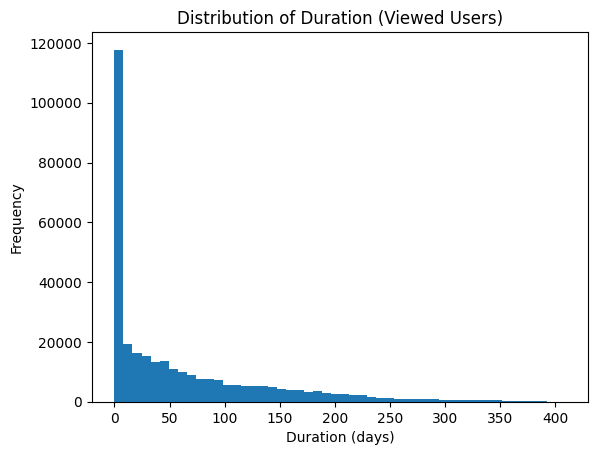

In [141]:
df_viewed = df[df["viewed"] == 1].copy()

plt.hist(df_viewed["duration"].dropna(), bins=50)
plt.xlabel("Duration (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Duration (Viewed Users)")
plt.show()

### 5.3.2 Defining Early-stage Duration

duration 분포를 바탕으로,
초기 구간을 정의하기 위한 기준을 설정하였다.

본 분석에서는 약 2주(14일)를 기준으로 초기 구간을 정의하였다.
이는 다음과 같은 이유에 기반한다:

- 학습 초기 온보딩 기간으로 해석 가능한 시간 범위
- 일정 수준의 학습 활동이 발생하기 전 단계로 볼 수 있는 구간
- 행동 변수의 축적 여부를 판단할 수 있는 최소 기간

이에 따라 duration ≤ 14일을 초기 이탈 구간으로 정의하고,
이를 기준으로 학습자를 구분하여 추가 분석을 수행한다.

In [142]:
df_viewed = df[df["viewed"] == 1].copy()

# duration 필요 → 결측 제거
df_viewed = df_viewed[df_viewed["duration"].notna()].copy()

# 초기 이탈 정의
df_viewed["early_dropout"] = (df_viewed["duration"] <= 14).astype(int)

# ROC용 positive class
df_viewed["sustained"] = (df_viewed["duration"] > 14).astype(int)

### Interpretation

duration을 기준으로 초기 구간을 정의함으로써,
단순히 강의에 진입했는지 여부를 넘어서
얼마나 빠르게 이탈하는지를 추가적으로 고려할 수 있게 되었다.

이는 초기 단계에서의 이탈을 보다 정교하게 이해하기 위한 보조적인 분석 관점이며,
이후 분석에서는 해당 구분을 기반으로
행동 변수와 초기 이탈 간의 관계를 살펴보고자 한다.

## 5.4 Statistical Tests and Effect Sizes

duration을 기준으로 정의된 초기 이탈 집단을 바탕으로,
행동 변수와 초기 이탈 간의 관계를 분석하였다.

구체적으로, viewed == 1 집단 내에서
duration ≤ 14일인 경우를 초기 이탈 집단,
duration > 14일인 경우를 유지 집단으로 구분하였다.

이후 두 집단 간의 행동 변수(nevents, ndays_act, nplay_video, nforum_posts)의
분포 차이를 Mann–Whitney U test를 통해 검정하고,
효과크기는 Cliff’s delta를 통해 평가하였다.

이를 통해 초기 구간에서 학습 지속 여부와 관련된 행동 수준의 차이를 확인하고자 한다.

In [143]:
# viewed 집단 기준
g0 = df_viewed[df_viewed["early_dropout"] == 1]  # early dropout
g1 = df_viewed[df_viewed["early_dropout"] == 0]  # sustained

cols = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]

for col in cols:
    x = g0[col].dropna()
    y = g1[col].dropna()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    delta = (2 * stat) / (len(x) * len(y)) - 1

    print(f"\n==== {col} ====")
    print("p-value:", p)
    print("Cliff's delta:", delta)
    print("median early_dropout:", np.median(x))
    print("median sustained:", np.median(y))


==== nevents ====
p-value: 0.0
Cliff's delta: -0.4499603316428622
median early_dropout: 27.0
median sustained: 140.0

==== ndays_act ====
p-value: 0.0
Cliff's delta: -0.7057423418975182
median early_dropout: 1.0
median sustained: 5.0

==== nplay_video ====
p-value: 0.0
Cliff's delta: -0.4226465689162393
median early_dropout: 8.0
median sustained: 33.0

==== nforum_posts ====
p-value: 0.0
Cliff's delta: -0.026122894992490098
median early_dropout: 0.0
median sustained: 0.0


### 5.5 ROC-based Threshold Search

early-stage에서는 PR 기반 threshold가 극단적인 값으로 도출되는 문제가 확인되었다.

이는 초기 구간에서 활동 변수의 분포가 제한적이며,
class imbalance의 영향이 상대적으로 크게 작용하기 때문이다.

이에 따라 threshold 탐색 방법을 ROC 기반으로 변경하였다.

ROC curve는 TPR과 FPR의 균형을 기반으로 threshold를 평가하며,
Youden’s J statistic (TPR - FPR)을 최대화하는 지점을 최적 threshold로 선정하였다.

In [144]:
def find_roc_threshold(x, y):
    fpr, tpr, thresholds = roc_curve(y, x)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)

    return {
        "threshold": thresholds[best_idx],
        "tpr": tpr[best_idx],
        "fpr": fpr[best_idx],
        "youden_j": youden_j[best_idx]
    }

cols = ["nevents", "ndays_act", "nplay_video"]

# sustained 기준
y = df_viewed["sustained"]

roc_results = []

for col in cols:
    x = df_viewed[col].fillna(0)
    result = find_roc_threshold(x, y)

    roc_results.append({
        "variable": col,
        "threshold": result["threshold"],
        "tpr": result["tpr"],
        "fpr": result["fpr"],
        "youden_j": result["youden_j"]
    })

roc_df = pd.DataFrame(roc_results)
display(roc_df)

,variable,threshold,tpr,fpr,youden_j
0,nevents,105.0,0.551993,0.201771,0.350222
1,ndays_act,3.0,0.754167,0.198829,0.555337
2,nplay_video,17.0,0.387613,0.150367,0.237247


### 5.6 Threshold Validation

ROC 기반으로 도출된 threshold의 유효성을 검증하기 위해,
각 변수에 대해 threshold를 기준으로 이진 구분을 수행한 뒤,
early_dropout 여부와의 관계를 카이제곱 검정을 통해 확인하였다.

또한 단순한 유의성 검정에 그치지 않고,
효과크기를 나타내는 Cramer's V를 함께 산출하여
실질적인 영향력을 평가하였다.

그 결과, 변수별로 early_dropout 여부와 통계적으로 유의한 관계가 확인되었으며,
특히 일부 변수에서는 비교적 높은 수준의 효과크기가 나타났다.

이는 ROC 기반 threshold가 단순한 분류 기준을 넘어,
초기 이탈 패턴을 반영하는 의미 있는 기준으로 작동함을 시사한다.

In [145]:
best_thresholds = dict(zip(roc_df["variable"], roc_df["threshold"]))

validation_results = []

for col in cols:
    thr = best_thresholds[col]
    temp_flag = (df_viewed[col].fillna(0) >= thr).astype(int)

    ct = pd.crosstab(temp_flag, df_viewed["sustained"])
    chi2, p, dof, expected = chi2_contingency(ct)

    n = ct.to_numpy().sum()
    r, c = ct.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

    validation_results.append({
        "variable": col,
        "threshold": thr,
        "p_value": p,
        "cramers_v": cramers_v
    })

validation_df = pd.DataFrame(validation_results)
display(validation_df)

,variable,threshold,p_value,cramers_v
0,nevents,105.0,0.0,0.349975
1,ndays_act,3.0,0.0,0.546590
2,nplay_video,17.0,0.0,0.256654


### Interpretation

ROC 기반 threshold를 적용한 검정 결과,
세 변수(nevents, ndays_act, nplay_video) 모두
early_dropout 여부와 통계적으로 유의한 관계를 가지는 것으로 나타났다.

특히 효과크기(Cramer's V)를 기준으로 비교했을 때,
ndays_act가 가장 높은 값을 보이며
초기 단계에서 학습 지속 여부를 설명하는 데 가장 중요한 변수로 확인되었다.

이는 초기 단계에서는 단순한 활동량의 총합(nevents)이나
특정 행동 유형(nplay_video)보다,
학습자가 며칠 동안 지속적으로 활동했는지가
초기 이탈 여부를 설명하는 데 더 중요한 역할을 한다는 점을 시사한다.

또한 nevents 역시 비교적 높은 효과크기를 보이며,
전체 활동량 또한 일정 수준 이상의 설명력을 가지는 것으로 나타났다.

반면 nplay_video는 상대적으로 낮은 효과크기를 보였으며,
초기 단계에서는 영상 소비와 같은 특정 행동보다는
전반적인 활동 지속성이 더 중요한 요인으로 작용하는 것으로 해석할 수 있다.

따라서 early-stage에서는 ndays_act를 중심 변수로 설정하는 것이
가장 타당한 기준으로 판단된다.

# 6. Mid-stage Analysis (Viewed → Explored)

초기 단계 분석을 통해, 학습 지속 여부는 초기 활동 일수와 밀접하게 관련되어 있음을 확인하였다.

다음으로는 실제 강의에 진입한 학습자들 중,
어떤 학습자가 단순 진입에 그치지 않고 explored 단계로 이어지는지를 분석하고자 한다.

퍼널 전환율 분석에서 확인한 바와 같이,
Viewed → Explored 구간은 전체 퍼널에서 가장 낮은 전환율을 보인 핵심 병목 구간이다.

이에 따라 본 단계에서는 viewed == 1 집단을 대상으로,
explored 여부에 따른 행동 변수 차이, threshold, 그리고 그 타당성을 순차적으로 검토한다.

## 6.1 Group Definition

mid-stage 분석에서는 강의에 실제로 진입한 학습자들만을 대상으로 한다.

이에 따라 viewed == 1인 관측치만을 필터링하여 분석을 진행하였다.

이후 해당 집단을 explored 여부에 따라 두 그룹으로 구분하였다:

- explored == 0 : 강의에 진입했지만 추가적인 학습으로 이어지지 않은 집단
- explored == 1 : 강의를 일정 수준 이상 학습한 집단

이러한 구분을 통해,
단순 진입 이후 실제 학습 참여로 이어지는 과정에서의 행동 차이를 분석하고자 한다.

In [146]:
df_v = df[df["viewed"] == 1].copy()

g0 = df_v[df_v["explored"] == 0]  # not explored
g1 = df_v[df_v["explored"] == 1]  # explored

print("Explored=0:", len(g0))
print("Explored=1:", len(g1))

Explored=0: 287777
Explored=1: 37584


## 6.2 Statistical Tests and Effect Sizes

explored 여부에 따라 학습자의 행동 수준에 차이가 존재하는지를 확인하기 위해,
주요 활동 변수(nevents, ndays_act, nplay_video, nforum_posts)에 대해
두 집단 간 분포 차이를 비교하였다.

비모수 검정인 Mann–Whitney U test를 사용하여 통계적 유의성을 확인하고,
효과크기는 Cliff’s delta를 통해 평가하였다.

이를 통해 강의 진입 이후 실제 학습 참여(explored)로 이어지는 과정에서,
어떤 행동 변수들이 중요한 역할을 하는지를 파악하고자 한다.

In [147]:
cols = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]

results = []

for col in cols:
    x = g0[col].dropna()
    y = g1[col].dropna()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    delta = (2 * stat) / (len(x) * len(y)) - 1

    results.append({
        "variable": col,
        "p_value": p,
        "cliffs_delta": delta,
        "median_g0": np.median(x),
        "median_g1": np.median(y)
    })

results_df = pd.DataFrame(results)
results_df

,variable,p_value,cliffs_delta,median_g0,median_g1
0,nevents,0.0,-0.743411,49.0,2127.0
1,ndays_act,0.0,-0.812846,2.0,27.0
2,nplay_video,0.0,-0.755699,14.0,318.0
3,nforum_posts,0.0,-0.057511,0.0,0.0


### Interpretation

분석 결과, explored 여부에 따라 주요 행동 변수에서
통계적으로 유의한 차이가 확인되었으며,
효과크기 또한 매우 크게 나타났다.

특히 ndays_act 변수는 Cliff’s delta가 -0.81로 나타나,
mid-stage에서 가장 강력한 설명 변수로 확인되었다.
이는 강의 진입 이후 일정 수준 이상의 활동 일수가 확보되지 않으면
실질적인 학습 참여(explored)로 이어지기 어렵다는 점을 시사한다.

또한 nplay_video와 nevents 역시 큰 효과크기를 보이며,
영상 소비량과 전체 활동량 또한 중요한 역할을 하는 것으로 나타났다.

반면 nforum_posts는 효과크기가 매우 작게 나타나,
mid-stage에서는 주요 설명 변수로 활용하기 어렵다고 판단된다.

이러한 결과는 mid-stage에서의 전환이 단순한 진입 여부가 아니라,
일정 수준 이상의 학습 활동 축적과 밀접하게 관련되어 있음을 보여준다.

이에 따라 다음 단계에서는 주요 행동 변수들을 기반으로
explored 여부를 구분할 수 있는 threshold를 탐색하고자 한다.

## 6.3 PR-based Threshold Search

앞선 분석을 통해, explored 여부는 행동 변수와 매우 밀접하게 관련되어 있음을 확인하였다.

이에 따라 본 단계에서는 주요 행동 변수(ndays_act, nevents, nplay_video)를 기반으로,
explored 여부를 구분할 수 있는 threshold를 탐색하고자 한다.

threshold 탐색은 precision-recall 기반으로 수행하였으며,
각 변수에 대해 가능한 cutoff를 변화시키면서
precision과 recall의 균형을 고려한 기준값을 도출하였다.

이를 통해 mid-stage에서 실제 학습 참여로 이어질 수 있는
행동 수준의 기준을 정의하고자 한다.

In [148]:
def find_pr_threshold(x, y):
    precision, recall, thresholds = precision_recall_curve(y, x)

    # thresholds는 precision/recall보다 길이가 1 짧음
    precision_adj = precision[:-1]
    recall_adj = recall[:-1]

    f1_scores = 2 * (precision_adj * recall_adj) / (precision_adj + recall_adj + 1e-9)
    idx = np.argmax(f1_scores)

    return {
        "threshold": thresholds[idx],
        "precision": precision_adj[idx],
        "recall": recall_adj[idx],
        "f1": f1_scores[idx]
    }

In [149]:
cols = ["nevents", "ndays_act", "nplay_video"]
y = df_v["explored"]

f1_results = []

for col in cols:
    x = df_v[col].fillna(0)
    result = find_pr_threshold(x, y)

    f1_results.append({
        "variable": col,
        "threshold": result["threshold"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"]
    })

f1_df = pd.DataFrame(f1_results)
display(f1_df)

,variable,threshold,precision,recall,f1
0,nevents,1274.0,0.685758,0.610712,0.646063
1,ndays_act,18.0,0.739215,0.646499,0.689755
2,nplay_video,170.0,0.597030,0.421403,0.494073


### Threshold Selection Strategy

mid-stage에서는 F1 기준으로 도출된 threshold를 최종 기준으로 채택하였다.

이는 early-stage와 달리 mid-stage에서는
행동 변수의 분포가 이미 크게 확장되어 있으며,
threshold 자체가 충분히 높은 수준으로 형성되기 때문이다.

실제로 ndays_act의 경우 threshold가 18로 도출되어,
초기 단계에 비해 훨씬 높은 수준의 학습 활동이 요구되는 것으로 나타났다.

이러한 상황에서 precision 기준을 추가적으로 적용할 경우,
threshold가 지나치게 높아져 일부 학습자만을 대상으로 하는
비현실적인 기준이 될 가능성이 있다.

따라서 mid-stage에서는 precision을 추가로 제한하기보다,
precision과 recall의 균형을 반영한 F1 기준을 사용하는 것이
보다 실용적인 기준 설정 방식으로 판단된다.

### Variable Comparison and Final Selection

변수별 threshold를 비교한 결과,
ndays_act, nevents, nplay_video 모두에서 기준값이 도출되었으나,
각 변수의 해석 가능성과 적용 가능성에는 차이가 존재하였다.

ndays_act의 경우 threshold가 18로 도출되었으며,
mid-stage에서 요구되는 학습 활동 수준을 직관적으로 설명할 수 있는 기준으로 해석된다.
또한 precision과 recall이 균형을 이루고 있어,
실질적인 전환 기준으로 활용 가능하다.

반면 nevents는 threshold가 1274로 매우 높은 수준으로 나타나,
실제 운영 기준으로 활용하기에는 해석이 어렵고 적용 가능성이 낮은 것으로 판단된다.

nplay_video 역시 threshold가 170으로 비교적 높은 수준이며,
precision과 recall 모두에서 ndays_act에 비해 성능이 낮게 나타났다.

이에 따라 본 분석에서는 mid-stage에서의 핵심 행동 기준으로
ndays_act 변수를 최종적으로 선택하였다.

## 6.4 Threshold Validation

앞선 단계에서 도출된 ndays_act ≥ 18 기준의 타당성을 검증하기 위해,
해당 기준을 이진 변수로 변환하고,
explored 여부와의 관계를 통계적으로 검정하였다.

이를 통해 해당 threshold가 실제로 학습 참여 여부를
유의하게 구분하는지를 확인하고자 한다.

In [150]:
best_thresholds = dict(zip(f1_df["variable"], f1_df["threshold"]))

df_v["nevents_high"] = (df_v["nevents"] >= best_thresholds["nevents"]).astype(int)
df_v["ndays_act_high"] = (df_v["ndays_act"] >= best_thresholds["ndays_act"]).astype(int)
df_v["nplay_video_high"] = (df_v["nplay_video"] >= best_thresholds["nplay_video"]).astype(int)

In [151]:
validation_results = []

for col in cols:
    thr = best_thresholds[col]
    temp_flag = (df_v[col].fillna(0) >= thr).astype(int)

    ct = pd.crosstab(temp_flag, df_v["explored"])
    chi2, p, dof, expected = chi2_contingency(ct)

    n = ct.to_numpy().sum()
    r, c = ct.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

    validation_results.append({
        "variable": col,
        "threshold": thr,
        "p_value": p,
        "cramers_v": cramers_v
    })

validation_df = pd.DataFrame(validation_results)
display(validation_df)

,variable,threshold,p_value,cramers_v
0,nevents,1274.0,0.0,0.604101
1,ndays_act,18.0,0.0,0.654101
2,nplay_video,170.0,0.0,0.448814


In [152]:
# 이진 변수 생성
df_v["ndays_act_flag"] = (df_v["ndays_act"] >= 18).astype(int)

df_v["ndays_act_flag"].value_counts()

ndays_act_flag
0    292491
1     32870
Name: count, dtype: int64

In [153]:
# 카이제곱 검정
cont = pd.crosstab(
    df_v["ndays_act_flag"],
    df_v["explored"]
)

chi2, p, _, _ = chi2_contingency(cont)

print(cont)
print("p-value:", p)

explored             0      1
ndays_act_flag               
0               279205  13286
1                 8572  24298
p-value: 0.0


In [154]:
# 효과크기: Cramer's V
n = cont.values.sum()
phi2 = chi2 / n
r, k = cont.shape

cramers_v = np.sqrt(phi2 / min(r - 1, k - 1))

print("Cramer's V:", cramers_v)

Cramer's V: 0.6541011750431305


### Interpretation

검정 결과, ndays_act ≥ 18 기준과 explored 여부 간에는
통계적으로 유의한 관계가 확인되었으며(p-value < 0.001),
효과크기(Cramer's V = 0.65) 또한 매우 크게 나타났다.

이는 강의 진입 이후 일정 수준 이상의 활동 일수가 확보되지 않을 경우,
실질적인 학습 참여(explored)로 이어지기 매우 어렵다는 점을 시사한다.

특히 ndays_act ≥ 18 기준은 단순한 행동 차이를 넘어,
mid-stage에서의 학습 전환 여부를 강하게 구분할 수 있는
핵심 행동 임계점으로 해석될 수 있다.

이러한 결과는 초기 단계보다 mid-stage에서
행동 변수의 영향력이 더욱 강화된다는 점을 보여주며,
학습자의 활동 지속성이 실제 학습 참여로 이어지는 데 있어
결정적인 역할을 한다는 것을 의미한다.

따라서 mid-stage에서는 "최소 18일 이상의 활동"을
핵심 관리 지표로 설정하는 것이 타당하며,
해당 기준에 도달하지 못하는 학습자에 대해서는
적극적인 참여 유도 전략이 필요할 것으로 판단된다.

# 7. Late-stage Analysis (Explored → Satisfied)

## 7.1 Group Definition

Late-stage 분석은 이미 강의를 일정 수준 이상 탐색한 학습자들을 대상으로,
그 이후의 학습 깊이 차이를 분석하는 단계이다.

즉, 본 단계에서는 단순히 강의에 진입했는지 여부가 아니라,
강의 내용을 얼마나 충분히 따라가며 학습했는지를 측정하는 데 목적이 있다.

이를 위해 분석 대상은 다음과 같이 정의한다.

- 분석 대상: explored == 1 인 학습자
- 결과 변수: satisfied

본 프로젝트에서는 `certified`를 late-stage의 결과 변수로 사용하지 않고,
대신 `satisfied`라는 개념을 새롭게 정의하여 사용한다.

이는 certified가 시험 통과 여부라는 '성과 결과'의 성격이 강한 반면,
late-stage에서는 학습 과정에서의 '충분한 참여 및 학습 깊이'를 측정하는 것이
더 적절하기 때문이다.

---

### satisfied 정의 방식

강의마다 전체 분량과 구조가 다르기 때문에,
모든 강의에 동일한 nchapters 기준을 적용하는 것은 적절하지 않다.

따라서 각 강의별로 기준을 따로 설정하는 방식으로 정의한다.

1. 기준 집단 정의:
   - certified == 1 이면서 explored == 1 인 학습자

2. 각 강의(course_id)별로
   해당 집단의 nchapters 분포에서 상위 퍼센타일(예: 75%) 값을 계산

3. 각 학습자에 대해:
   - nchapters >= 해당 강의 기준값 → satisfied = 1
   - 그렇지 않으면 → satisfied = 0

---

이러한 방식은 다음과 같은 장점을 가진다.

- 강의 간 분량 차이를 보정할 수 있음
- 단순 활동량이 아니라 '상대적인 학습 깊이'를 반영할 수 있음
- certified를 직접 사용하지 않고도, 학습 충실도를 측정할 수 있음

---

따라서 Late-stage 분석은 다음과 같이 정리된다.

- 모집단: explored == 1
- 목표 변수: satisfied
- 목적: 탐색 이후 학습 깊이에 영향을 미치는 요인을 분석

In [155]:
# 복사
late_df = df.copy()

# -----------------------------
# 1. 기준 집단 정의
# -----------------------------
certified_clean = late_df[
    (late_df["certified"] == 1) &
    (late_df["explored"] == 1) &
    (late_df["nchapters"].notna())
].copy()

print("certified_clean:", certified_clean.shape)

# -----------------------------
# 2. course별 threshold 계산
# -----------------------------
p75_series = (
    certified_clean
    .groupby("course_id")["nchapters"]
    .quantile(0.75)
)

print(p75_series.head())

# -----------------------------
# 3. map으로 threshold 붙이기 (merge X)
# -----------------------------
late_df["nchapters_p75"] = late_df["course_id"].map(p75_series)

# -----------------------------
# 4. satisfied 생성
# -----------------------------
late_df["satisfied"] = np.where(
    late_df["nchapters_p75"].notna(),
    (late_df["nchapters"] >= late_df["nchapters_p75"]).astype(int),
    np.nan
)

# -----------------------------
# 5. Late-stage 데이터 정의
# -----------------------------
late_stage = late_df[
    (late_df["explored"] == 1) &
    (late_df["satisfied"].notna())
].copy()

print("late_stage:", late_stage.shape)

late_stage["satisfied"].value_counts()

certified_clean: (16984, 33)
course_id
HarvardX/CB22x/2013_Spring     27.0
HarvardX/CS50x/2012            12.0
HarvardX/ER22x/2013_Spring     33.0
HarvardX/PH207x/2012_Fall      16.0
HarvardX/PH278x/2013_Spring     9.0
Name: nchapters, dtype: float64
late_stage: (37584, 33)


satisfied
0.0    25714
1.0    11870
Name: count, dtype: int64

## 7.2 Statistical Tests and Effect Sizes

Late-stage에서는 satisfied 여부에 따라 학습 행동 변수들이
유의미한 차이를 보이는지 확인한다.

비교 대상 변수는 다음과 같다.

- nevents
- ndays_act
- nplay_video

---

### 분석 방법

- 두 집단 비교: satisfied = 0 vs 1
- 검정 방법: Mann-Whitney U test
- 효과 크기: Cliff's Delta

---

이를 통해 단순 유의성뿐 아니라,
실제 효과 크기가 얼마나 큰지를 함께 평가한다.

In [156]:
def cliffs_delta(x, y):
    import numpy as np
    nx = len(x)
    ny = len(y)
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (nx * ny)

variables = ["nevents", "ndays_act", "nplay_video"]

results = []

for var in variables:
    g0 = late_stage[late_stage["satisfied"] == 0][var].dropna().values
    g1 = late_stage[late_stage["satisfied"] == 1][var].dropna().values
    
    if len(g0) == 0 or len(g1) == 0:
        continue
    
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    delta = cliffs_delta(g0, g1)
    
    results.append({
        "variable": var,
        "p_value": p,
        "cliffs_delta": delta,
        "median_0": np.median(g0),
        "median_1": np.median(g1)
    })

pd.DataFrame(results)

,variable,p_value,cliffs_delta,median_0,median_1
0,nevents,3.507834e-107,-0.140891,1933.0,3468.0
1,ndays_act,0.000000e+00,-0.267947,23.0,40.0
2,nplay_video,0.000000e+00,-0.404061,239.0,581.0


## 7.3 ROC-based Threshold Search

Late-stage에서는 각 변수에 대해 satisfied를 예측하는 threshold를
ROC 기반으로 탐색한다.

기준은 Youden’s J statistic을 사용한다.

- J = TPR - FPR

이를 최대화하는 threshold를 선택한다.

이 방식은 threshold 선택을 데이터 기반으로 수행할 수 있게 해준다.

In [157]:
def find_roc_threshold(y_score, y_true):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    
    return {
        "threshold": thresholds[best_idx],
        "tpr": tpr[best_idx],
        "fpr": fpr[best_idx],
        "j_stat": j_scores[best_idx]
    }

In [158]:
variables = ["nevents", "ndays_act", "nplay_video"]

roc_results = []

for var in variables:
    result = find_roc_threshold(
        late_stage[var].fillna(0),
        late_stage["satisfied"]
    )
    
    result["variable"] = var
    roc_results.append(result)

roc_df = pd.DataFrame(roc_results)
roc_df

,threshold,tpr,fpr,j_stat,variable
0,4971.0,0.415670,0.196858,0.218812,nevents
1,40.0,0.503960,0.261025,0.242934,ndays_act
2,409.0,0.365712,0.223497,0.142215,nplay_video


ROC 기반 threshold 탐색 결과, late-stage에서 `satisfied`를 가장 잘 구분한 변수는 `ndays_act`였다.
이는 후기 학습 단계에서 단순 활동량 자체보다도,
학습이 여러 날에 걸쳐 지속되었는지가 더 중요한 기준임을 시사한다.

반면 `nplay_video`의 분리력은 상대적으로 낮게 나타났다.
이는 영상 시청 행동만으로는 후기 학습 충실도를 충분히 설명하기 어렵고,
실제 만족 수준은 보다 지속적이고 누적적인 학습 참여와 관련될 가능성을 보여준다.

`nevents`는 일정 수준의 구분력을 보였으나,
`ndays_act`보다는 낮은 수준이었다.
따라서 late-stage에서는 '얼마나 많이 클릭했는가'보다
'얼마나 꾸준히 학습했는가'가 더 핵심적인 신호로 해석된다.

## 7.4 Threshold Validation

도출된 threshold가 실제로 의미 있는 구분을 만들어내는지 검증한다.

이를 위해 다음을 수행한다.

- threshold 기준으로 그룹 분할
- satisfied와의 독립성 검정 (Chi-square test)
- 효과 크기 측정 (Cramér's V)

이를 통해 threshold의 실질적 설명력을 평가한다.

In [159]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

validation_results = []

for _, row in roc_df.iterrows():
    var = row["variable"]
    thr = row["threshold"]
    
    temp = late_stage[[var, "satisfied"]].copy()
    temp = temp.dropna()
    
    temp["high_group"] = (temp[var] >= thr).astype(int)
    
    ct = pd.crosstab(temp["high_group"], temp["satisfied"])
    
    # 2x2 형태가 안 나오는 예외 방지
    if ct.shape != (2, 2):
        print(f"{var}: contingency table shape = {ct.shape}, skipped")
        continue
    
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct.values)
    
    validation_results.append({
        "variable": var,
        "threshold": thr,
        "p_value": p,
        "cramers_v": v
    })

validation_df = pd.DataFrame(validation_results)
validation_df["p_value"] = validation_df["p_value"].round(6)
validation_df["cramers_v"] = validation_df["cramers_v"].round(4)

validation_df

,variable,threshold,p_value,cramers_v
0,nevents,4971.0,0.0,0.2301
1,ndays_act,40.0,0.0,0.2387
2,nplay_video,409.0,0.0,0.2805


## 7.4 Threshold Validation

ROC 기반으로 도출된 threshold가 실제로 `satisfied` 집단을 유의미하게 구분하는지를 검증하기 위해,
각 변수별 threshold를 기준으로 학습자를 두 그룹으로 나누고,
`satisfied`와의 연관성을 분석하였다.

이를 위해 카이제곱 검정을 수행하였으며,
효과 크기는 Cramér’s V를 통해 측정하였다.

---

### 분석 결과

- `nevents`: Cramér’s V = 0.2301
- `ndays_act`: Cramér’s V = 0.2387
- `nplay_video`: Cramér’s V = 0.2805

모든 변수에서 p-value가 매우 작게 나타나,
threshold를 기준으로 나눈 그룹과 `satisfied` 간에는 통계적으로 유의미한 연관성이 존재함을 확인할 수 있었다.

---

### 해석

세 변수 중 `nplay_video`가 가장 높은 Cramér’s V 값을 보여,
late-stage에서 `satisfied`를 설명하는 데 가장 강한 변수로 나타났다.

이는 후기 학습 단계에서는 단순한 활동 횟수나 학습 일수보다,
실제 콘텐츠 소비 행동(영상 시청)이 더 직접적으로 학습 충실도를 반영할 가능성을 시사한다.

한편, ROC 기반 threshold 탐색에서는 `ndays_act`가 가장 높은 분리력을 보였으나,
validation 단계에서는 `nplay_video`가 더 높은 연관성을 나타냈다.

이러한 차이는 다음과 같이 해석할 수 있다.

- `ndays_act`는 "임계점 형성"에 강한 변수  
  → 일정 기간 이상 학습을 지속해야 만족 수준에 도달할 가능성이 높음

- `nplay_video`는 "실제 학습 충실도"를 가장 잘 반영하는 변수  
  → 얼마나 많이 콘텐츠를 소비했는지가 만족 수준과 더 직접적으로 연결됨

---

### 종합 해석

Late-stage에서는 단순히 학습에 오래 참여하는 것뿐만 아니라,
실제 콘텐츠를 얼마나 충분히 소비했는지가 중요하다.

즉,

- 지속성 (ndays_act) → 만족에 도달하기 위한 필요 조건
- 콘텐츠 소비 (nplay_video) → 만족을 결정짓는 핵심 요인

으로 해석할 수 있다.

# Chapter 8. Integrated Insights & Actionable Strategy

## 8.1 Funnel-Level Integrated Interpretation

본 프로젝트에서는 학습자의 행동을 다음과 같은 퍼널 구조로 정의하였다.

- Registered → Viewed → Explored → Satisfied

각 단계는 단순한 행동 순서가 아니라,
서로 다른 성격의 학습 참여 단계를 의미한다.

---

### Early-stage (Registered → Viewed)

Early-stage에서는 학습자가 강의에 실제로 진입하는지 여부가 핵심이다.

이 단계에서는 비교적 낮은 수준의 행동 신호만으로도
이탈 여부가 크게 갈리는 특징을 보였다.

즉, 초기 진입은 강한 engagement 없이도 발생할 수 있으며,
작은 행동 차이가 큰 이탈로 이어지는 구간이다.

---

### Mid-stage (Viewed → Explored)

Mid-stage에서는 학습자가 단순히 강의를 확인하는 수준을 넘어서,
실제 콘텐츠를 탐색하는 단계로 넘어가는지가 중요하다.

이 단계에서는 활동량과 참여도가 본격적으로 중요해지며,
학습자의 engagement 수준이 탐색 여부를 결정짓는 핵심 요인으로 작용한다.

---

### Late-stage (Explored → Satisfied)

Late-stage에서는 학습자가 얼마나 깊이 있게 학습했는지가 핵심이다.

분석 결과, 이 단계에서는 단순 활동량보다도

- 학습 지속성 (ndays_act)
- 콘텐츠 소비 (nplay_video)

가 중요한 역할을 하는 것으로 나타났다.

특히, 콘텐츠 소비 행동이 실제 만족 수준을 가장 강하게 설명하는 변수로 확인되었다.

---

### 전체 퍼널 구조 요약

각 단계는 서로 다른 기준으로 학습자를 구분한다.

- Early-stage: 진입 여부
- Mid-stage: 참여 수준
- Late-stage: 학습 깊이

따라서 학습자 이탈을 단일 기준으로 설명하기보다는,
단계별로 서로 다른 요인을 고려하는 접근이 필요하다.

## 8.2 Key Behavioral Drivers Across Stages

각 퍼널 단계에서 학습자 행동을 설명하는 핵심 변수는 다음과 같이 정리할 수 있다.

---

### Early-stage

- 핵심: 초기 진입 여부
- 특징: 낮은 수준의 행동 신호에도 큰 차이 발생

---

### Mid-stage

- 핵심: 학습 참여 (engagement)
- 주요 변수:
  - nevents
  - ndays_act

- 특징:
  - 활동량 증가에 따라 탐색(explored) 확률 증가

---

### Late-stage

- 핵심: 학습 깊이 (depth of learning)
- 주요 변수:
  - ndays_act
  - nplay_video

- 특징:
  - 지속적인 참여 + 콘텐츠 소비가 결합되어야 만족(satisfied)에 도달

---

### 종합

퍼널이 진행될수록 학습자 행동의 요구 수준이 점점 높아진다.

- 초기: 진입만 하면 됨
- 중기: 적극적 참여 필요
- 후기: 지속적 학습 + 콘텐츠 소비 필요

## 8.3 Actionable Insights for MOOC Operators

본 분석 결과는 MOOC 운영자에게 다음과 같은 실질적인 전략적 인사이트를 제공한다.

---

### 1. Early-stage: 진입 장벽 최소화

초기 단계에서는 작은 행동 차이가 큰 이탈로 이어진다.

따라서 다음과 같은 전략이 필요하다.

- 강의 시작 직후의 onboarding 경험 개선
- 첫 클릭 또는 첫 콘텐츠 접근을 유도하는 UX 설계
- 초기 알림 및 리마인드 강화

---

### 2. Mid-stage: 참여 유도 전략

Mid-stage에서는 학습자의 engagement 수준이 핵심이다.

따라서:

- 활동을 유도하는 인터랙션 요소 추가
- 중간 단계 리텐션 장치 (quiz, checkpoint 등)
- 일정 수준 활동이 발생하도록 유도

---

### 3. Late-stage: 콘텐츠 소비 극대화

Late-stage에서는 콘텐츠 소비가 가장 중요한 변수로 나타났다.

따라서:

- 영상 시청을 유도하는 구조 설계
- 콘텐츠 완주를 유도하는 UI/UX
- 추천 시스템 또는 다음 콘텐츠 자동 연결

---

### 핵심 메시지

학습자의 이탈을 줄이기 위해서는
단일 전략이 아니라 단계별 맞춤 전략이 필요하다.

- Early: 진입 유도
- Mid: 참여 유지
- Late: 학습 완주 유도

특히, 최종적으로 만족(satisfied)에 도달하기 위해서는
단순 참여를 넘어 실제 콘텐츠 소비가 필수적이다.